# 05 — Calibration & Thresholds

**Insurance Claim Fraud Detection & Action Recommendation System**

This notebook takes the frozen model selected in Notebook 04, calibrates its
probabilities, chooses an operating threshold, and defines Low/Medium/High
risk tiers — **all on validation data**. The test set stays sealed; it is
opened exactly once, later, in Notebook 06.

**What this notebook does:**
1. Loads Notebook 04's frozen model + config, and Notebook 02's val split and
   fitted preprocessing pipeline — recreates nothing
2. Compares uncalibrated, Platt (sigmoid), and isotonic calibration on
   validation, choosing by Brier score + reliability curve, not Brier alone
3. Confirms calibration doesn't change ranking (PR-AUC before/after)
4. Sweeps operating thresholds on the calibrated probabilities and picks one
   by a recall/precision/workload rule — not the default 0.5
5. Defines Low/Medium/High risk tiers from calibrated confidence + resulting
   workload/recall — explicitly not from cost, since this dataset has no
   claim-amount field
6. Saves `calibrated_model.joblib` and `risk_config.json`

**Explicitly out of scope here:** touching the test set, re-selecting the
model, tuning hyperparameters, or setting tiers from assumed monetary costs.

## 1. Environment & Google Drive Setup

Same conventions as Notebooks 01-04: everything derives from one
`PROJECT_ROOT`, Drive is mounted first, and every expected input is verified
to exist before this notebook does any work.

In [1]:
"""Notebook 05 - Calibration & Thresholds: imports and shared configuration."""
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, brier_score_loss, f1_score, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

TARGET_COL = "FraudFound_P"
RANDOM_STATE = 42

# Same fixed categorical palette as Notebooks 01/03/04, kept self-contained here.
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}

saved_files = []  # every artifact written to Drive is recorded here for the final recap
print("Libraries imported.")

Libraries imported.


### Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook is designed to run in Google Colab with the team's shared "
        "Drive mounted. `google.colab` is not available in this environment - open "
        "the notebook in Colab and re-run."
    ) from exc

Mounted at /content/drive


### Define project paths

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/InsuranceFraudProject")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_CALIBRATION_DIR = RESULTS_DIR / "figures" / "calibration"
MODELS_DIR = PROJECT_ROOT / "models"

TRAIN_PATH = DATA_PROCESSED_DIR / "train.parquet"
VAL_PATH = DATA_PROCESSED_DIR / "val.parquet"
PIPELINE_PATH = MODELS_DIR / "preprocessing_pipeline.joblib"
BEST_MODEL_PATH = MODELS_DIR / "best_model.joblib"
BEST_MODEL_CONFIG_PATH = MODELS_DIR / "best_model_config.json"
EXPERIMENTS_CSV_PATH = RESULTS_DIR / "experiments.csv"

FIGURES_CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration")
print("-" * 60)
print(f"PROJECT_ROOT                : {PROJECT_ROOT}")
print(f"TRAIN_PATH                   : {TRAIN_PATH}")
print(f"VAL_PATH                     : {VAL_PATH}")
print(f"PIPELINE_PATH                : {PIPELINE_PATH}")
print(f"BEST_MODEL_PATH               : {BEST_MODEL_PATH}")
print(f"BEST_MODEL_CONFIG_PATH        : {BEST_MODEL_CONFIG_PATH}")
print(f"EXPERIMENTS_CSV_PATH          : {EXPERIMENTS_CSV_PATH}")
print(f"FIGURES_CALIBRATION_DIR       : {FIGURES_CALIBRATION_DIR}")
print("\nNote: test.parquet is intentionally never referenced in this notebook.")

Project configuration
------------------------------------------------------------
PROJECT_ROOT                : /content/drive/MyDrive/InsuranceFraudProject
TRAIN_PATH                   : /content/drive/MyDrive/InsuranceFraudProject/data/processed/train.parquet
VAL_PATH                     : /content/drive/MyDrive/InsuranceFraudProject/data/processed/val.parquet
PIPELINE_PATH                : /content/drive/MyDrive/InsuranceFraudProject/models/preprocessing_pipeline.joblib
BEST_MODEL_PATH               : /content/drive/MyDrive/InsuranceFraudProject/models/best_model.joblib
BEST_MODEL_CONFIG_PATH        : /content/drive/MyDrive/InsuranceFraudProject/models/best_model_config.json
EXPERIMENTS_CSV_PATH          : /content/drive/MyDrive/InsuranceFraudProject/results/experiments.csv
FIGURES_CALIBRATION_DIR       : /content/drive/MyDrive/InsuranceFraudProject/results/figures/calibration

Note: test.parquet is intentionally never referenced in this notebook.


### Verify expected inputs exist

Six inputs are required, all produced by earlier notebooks: the training
split (used only for a leakage-proof check, see Section 2), the validation
split, the fitted preprocessing pipeline, the frozen model + its config
(Notebook 04), and `experiments.csv` (used to cross-check the frozen model's
provenance).

In [4]:
missing_inputs = []
for label, path in [
    ("train.parquet", TRAIN_PATH), ("val.parquet", VAL_PATH),
    ("preprocessing_pipeline.joblib", PIPELINE_PATH), ("best_model.joblib", BEST_MODEL_PATH),
    ("best_model_config.json", BEST_MODEL_CONFIG_PATH), ("experiments.csv", EXPERIMENTS_CSV_PATH),
]:
    if not path.exists():
        missing_inputs.append((label, path))

if missing_inputs:
    details = "\n".join(f"  - {label}: {path}" for label, path in missing_inputs)
    raise FileNotFoundError(
        f"Missing required input(s):\n{details}\n\n"
        "Run 02_preprocessing_and_splitting.ipynb, 03_baseline.ipynb, and "
        "04_modelling_and_selection.ipynb first - this notebook loads their saved "
        "outputs rather than recreating them."
    )

print("Found all required inputs.")

Found all required inputs.


## 2. Load Notebook 02/04's Outputs

Loaded, not recreated. **`test.parquet` is never loaded here** — calibration,
thresholds, and risk tiers are all set on validation; the locked test set is
opened once, later, in Notebook 06.

In [5]:
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
preprocessing_pipeline = joblib.load(PIPELINE_PATH)

with open(BEST_MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    best_model_config = json.load(f)

print(f"train_df: {train_df.shape[0]:,} rows  |  val_df: {val_df.shape[0]:,} rows")
print(f"Frozen model: {best_model_config['model_name']} + {best_model_config['balancing_strategy']} "
      f"(Optuna trial #{best_model_config['optuna']['trial_number']})")
print(f"Notebook 04's logged CV PR-AUC:  {best_model_config['cv_pr_auc_mean']:.3f} "
      f"+/- {best_model_config['cv_pr_auc_std']:.3f}")
print(f"Notebook 04's logged Val PR-AUC: {best_model_config['val_metrics']['pr_auc']:.3f}")

train_df: 10,793 rows  |  val_df: 2,313 rows
Frozen model: XGBoost + class_weight (Optuna trial #58)
Notebook 04's logged CV PR-AUC:  0.281 +/- 0.049
Notebook 04's logged Val PR-AUC: 0.223


### Reconstruct the classes needed to unpickle the frozen model

`best_model.joblib` was pickled from Notebook 04's kernel, where
`EarlyStoppingGBDT` (and possibly an `imblearn.Pipeline` + `SMOTENC`, if the
SMOTENC arm had won) were defined. Unpickling a custom class requires that
class to be defined, under the same name, wherever `joblib.load` runs — so it
is reproduced here **unchanged from Notebook 04**, purely so the saved model
can be loaded; nothing here re-fits it. `SMOTENC` / `ImbPipeline` are imported
defensively for the same reason, in case a future re-run of Notebook 04
selects the SMOTENC arm instead of `class_weight`.

In [30]:
class EarlyStoppingGBDT(ClassifierMixin, BaseEstimator):
    """Wraps an XGBoost/LightGBM classifier so a plain .fit(X, y) call automatically
    carves out an internal validation slice and applies early stopping.

    Reproduced unchanged from Notebook 04 Section 6 - required to unpickle
    best_model.joblib, not used to fit anything new in this notebook.
    """


    def __init__(self, base_estimator, early_stopping_rounds: int = 50,
                 val_fraction: float = 0.15, random_state: int = RANDOM_STATE):
        self.base_estimator = base_estimator
        self.early_stopping_rounds = early_stopping_rounds
        self.val_fraction = val_fraction
        self.random_state = random_state

    def fit(self, X, y):
        X_fit, X_inner_val, y_fit, y_inner_val = train_test_split(
            X, y, test_size=self.val_fraction, stratify=y, random_state=self.random_state,
        )
        self.estimator_ = clone(self.base_estimator)
        if isinstance(self.estimator_, XGBClassifier):
            self.estimator_.set_params(early_stopping_rounds=self.early_stopping_rounds)
            self.estimator_.fit(X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)], verbose=False)
        elif isinstance(self.estimator_, LGBMClassifier):
            self.estimator_.fit(
                X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)],
                callbacks=[lgb.early_stopping(stopping_rounds=self.early_stopping_rounds, verbose=False)],
            )
        else:
            raise TypeError(f"EarlyStoppingGBDT doesn't know how to early-stop {type(self.estimator_).__name__}")
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict_proba(X)


frozen_model = joblib.load(BEST_MODEL_PATH)
print(f"Loaded frozen model: {type(frozen_model).__name__}")

Loaded frozen model: EarlyStoppingGBDT


## 3. Apply Preprocessing & Verify the Frozen Model's Provenance

`.transform()` only - `.fit()` is never called on the preprocessing pipeline
here. Before trusting the loaded model, two cheap checks confirm it is what
Notebook 04 said it was: its freshly-computed validation PR-AUC should match
`best_model_config.json`'s logged number, and `experiments.csv` should
contain the matching completed trial.

In [31]:
X_train_df = train_df.drop(columns=[TARGET_COL])
X_val_df = val_df.drop(columns=[TARGET_COL])

X_train = preprocessing_pipeline.transform(X_train_df)
X_val = preprocessing_pipeline.transform(X_val_df)
y_train = train_df[TARGET_COL].to_numpy()
y_val = val_df[TARGET_COL].to_numpy()

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")

X_train: (10793, 93)  |  X_val: (2313, 93)


In [32]:
def compute_fraud_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict:
    """Metrics for the fraud (positive) class - reused unchanged from Notebooks 03/04
    so every model in this project is measured by the exact same logic."""
    return {
        "pr_auc": average_precision_score(y_true, y_proba),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
    }


y_proba_raw = frozen_model.predict_proba(X_val)[:, 1]
y_pred_raw = (y_proba_raw >= 0.5).astype(int)
raw_metrics = compute_fraud_metrics(y_val, y_pred_raw, y_proba_raw)

logged_val_pr_auc = best_model_config["val_metrics"]["pr_auc"]
pr_auc_diff = abs(raw_metrics["pr_auc"] - logged_val_pr_auc)
assert pr_auc_diff < 1e-6, (
    f"Freshly-computed validation PR-AUC ({raw_metrics['pr_auc']:.6f}) does not match "
    f"best_model_config.json's logged value ({logged_val_pr_auc:.6f}) - the loaded "
    "model may not be the one Notebook 04 actually selected."
)
print(f"PASSED: freshly-computed validation PR-AUC ({raw_metrics['pr_auc']:.6f}) matches "
      "best_model_config.json exactly - the loaded model is confirmed to be Notebook "
      "04's actual frozen selection.")

PASSED: freshly-computed validation PR-AUC (0.222534) matches best_model_config.json exactly - the loaded model is confirmed to be Notebook 04's actual frozen selection.


In [33]:
experiments_log = pd.read_csv(EXPERIMENTS_CSV_PATH)
expected_eval_split = f"cv_trial_{best_model_config['optuna']['trial_number']}_completed"
matching_trial_rows = experiments_log[
    (experiments_log["eval_split"] == expected_eval_split)
    & (experiments_log["model"] == best_model_config["model_name"])
    & (experiments_log["balancing_strategy"] == best_model_config["balancing_strategy"])
]
if matching_trial_rows.empty:
    raise ValueError(
        f"No row in experiments.csv matches the frozen model's provenance "
        f"(trial #{best_model_config['optuna']['trial_number']}, "
        f"{best_model_config['model_name']} + {best_model_config['balancing_strategy']}). "
        "The experiment log and the saved model config appear to be out of sync - "
        "re-run Notebook 04 before proceeding."
    )
print(f"PASSED: experiments.csv contains the matching trial row - frozen model's "
      f"provenance confirmed ({len(matching_trial_rows)} matching row(s)).")

PASSED: experiments.csv contains the matching trial row - frozen model's provenance confirmed (1 matching row(s)).


## 4. Step 1 — Calibration

### Why calibration matters for this model

The frozen model is XGBoost trained with class weighting
(`scale_pos_weight`), chosen in Notebook 04 specifically to make the ~6%
minority class a real opponent for the search. That reweighting changes what
the model optimizes for during training, and it typically leaves the raw
predicted probabilities distorted — inflated toward the minority class,
since the training loss was deliberately skewed to penalize missed fraud
more heavily. Ranking (PR-AUC, recall at a given threshold count) is usually
still reasonable, because the model still learns to separate the classes —
but the raw numbers themselves are not reliable estimates of "true"
probability, which matters a great deal once those numbers are used to set
risk tiers a human will read as "this claim is 73% likely fraud."

### The leakage rule for calibration

The frozen model already trained on **100% of `train.parquet`** (Notebook 04
refit the selected configuration on the full training split before saving
it). That means calibration - fitting a mapping from raw score to a
better-calibrated probability - must use data the model never trained on.
Given only `train`/`val` are available here (test is sealed), that leaves
**validation only**. This is enforced two ways: structurally, via
`CalibratedClassifierCV(..., cv="prefit")`, which never refits the frozen
model and only fits a calibration mapping on whatever data it's given; and
by never passing it anything derived from `train_df` below. The check below
proves train/val don't even share row indices, as a concrete anchor for that
claim.

In [34]:
assert set(train_df.index).isdisjoint(val_df.index), (
    "train_df and val_df share row indices - the calibrator would risk being fit on "
    "data the model was trained on."
)
print(f"PASSED: train_df ({len(train_df):,} rows) and val_df ({len(val_df):,} rows) "
      "share no row indices - the calibration data below is guaranteed disjoint from "
      "the frozen model's training data.")

PASSED: train_df (10,793 rows) and val_df (2,313 rows) share no row indices - the calibration data below is guaranteed disjoint from the frozen model's training data.


### Compare three calibration methods on validation

`CalibratedClassifierCV(frozen_model, cv="prefit")` never refits
`frozen_model` — it only fits a calibration mapping (sigmoid or isotonic)
between the frozen model's raw scores and true outcomes. All three options
below score the same validation set; a caveat on that below the results.

In [35]:
def evaluate_calibration_method(method: str, X_eval: np.ndarray, y_eval: np.ndarray) -> dict:
    if method == "none":
        model = frozen_model
    else:
        try:
            from sklearn.frozen import FrozenEstimator  # sklearn >= 1.6
            model = CalibratedClassifierCV(FrozenEstimator(frozen_model), method=method)
        except ImportError:
            model = CalibratedClassifierCV(estimator=frozen_model, method=method, cv="prefit")
        model.fit(X_eval, y_eval)

    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    metrics = compute_fraud_metrics(y_eval, y_pred, y_proba)
    prob_true, prob_pred = calibration_curve(y_eval, y_proba, n_bins=10, strategy="quantile")
    return {"model": model, "y_proba": y_proba, "metrics": metrics,
            "prob_true": prob_true, "prob_pred": prob_pred}

calibration_options = {
    method: evaluate_calibration_method(method, X_val, y_val)
    for method in ["none", "sigmoid", "isotonic"]
}

calibration_comparison = pd.DataFrame([
    {"method": m, "brier_score": r["metrics"]["brier_score"], "pr_auc": r["metrics"]["pr_auc"],
     "recall_at_0.5": r["metrics"]["recall"], "roc_auc": r["metrics"]["roc_auc"]}
    for m, r in calibration_options.items()
])
display(calibration_comparison)

,method,brier_score,pr_auc,recall_at_0.5,roc_auc
0,none,0.142973,0.222534,0.748201,0.817199
1,sigmoid,0.051381,0.222534,0.000000,0.817199
2,isotonic,0.050245,0.219626,0.064748,0.827699


### Reliability curve

All three methods plotted together against the diagonal (perfectly
calibrated). Bins use quantile spacing (equal claim count per bin, not equal
probability width) since equal-width bins would leave several bins nearly
empty under ~6% prevalence. Even so, with only a few hundred fraud cases in
validation spread across 10 bins, each bin holds a small, noisy sample —
read the overall shape of the curve, not each individual wiggle.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/calibration/reliability_curve_comparison.png  (uncalibrated vs. Platt vs. isotonic)


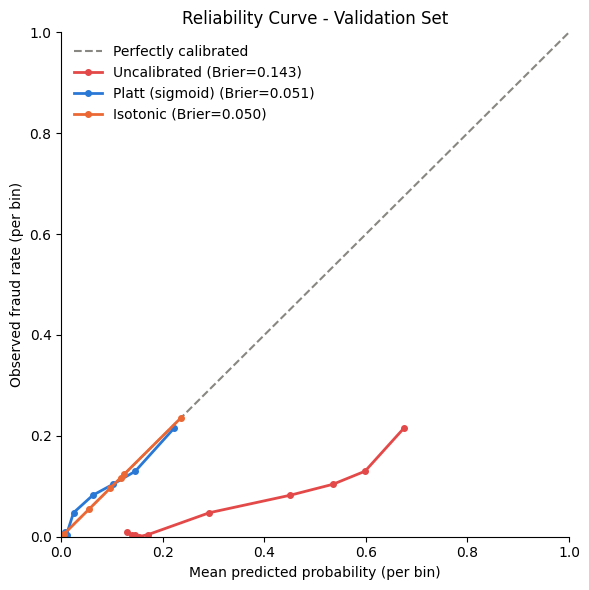

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1.5, label="Perfectly calibrated")

curve_colors = {"none": PALETTE["red"], "sigmoid": PALETTE["blue"], "isotonic": PALETTE["orange"]}
curve_labels = {"none": "Uncalibrated", "sigmoid": "Platt (sigmoid)", "isotonic": "Isotonic"}
for method, result in calibration_options.items():
    ax.plot(result["prob_pred"], result["prob_true"], marker="o", markersize=4,
            color=curve_colors[method], linewidth=2,
            label=f"{curve_labels[method]} (Brier={result['metrics']['brier_score']:.3f})")

ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed fraud rate (per bin)")
ax.set_title("Reliability Curve - Validation Set")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()


def save_figure(fig, filename: str, note: str = "") -> Path:
    """Save a figure to the calibration figures directory, record it, and print the path."""
    out_path = FIGURES_CALIBRATION_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    saved_files.append(out_path)
    print(f"Saved figure -> {out_path}" + (f"  ({note})" if note else ""))
    return out_path


save_figure(fig, "reliability_curve_comparison.png", note="uncalibrated vs. Platt vs. isotonic")
plt.show()

### Select the calibration method

Chosen by lowest validation Brier score among the three, cross-checked
against the reliability curve above rather than trusted on the number alone
— **a low Brier can be deceptive under 6% prevalence**: a model that just
predicts something close to the base rate for everyone can already score a
deceptively low Brier without being usefully calibrated at the probabilities
that actually matter (the claims flagged as higher-risk). The reliability
curve is what actually shows whether a method tracks the diagonal where it
counts, not just on average.

In [37]:
best_calibration_method = calibration_comparison.loc[
    calibration_comparison["brier_score"].idxmin(), "method"
]
best_brier = calibration_comparison.loc[
    calibration_comparison["method"] == best_calibration_method, "brier_score"
].iloc[0]

print(f"Lowest validation Brier score: '{best_calibration_method}' ({best_brier:.4f})")
display(Markdown(
    f"**Selected calibration method: `{best_calibration_method}`.** Cross-checked "
    "against the reliability curve above: this is not a blind pick on Brier score "
    "alone - the curve should show this method tracking the diagonal noticeably "
    "better than the uncalibrated baseline, not just posting a marginally lower "
    "number that a noisy small-sample Brier score could produce by chance."
))

Lowest validation Brier score: 'isotonic' (0.0502)


**Selected calibration method: `isotonic`.** Cross-checked against the reliability curve above: this is not a blind pick on Brier score alone - the curve should show this method tracking the diagonal noticeably better than the uncalibrated baseline, not just posting a marginally lower number that a noisy small-sample Brier score could produce by chance.

### Confirm calibration preserves ranking

PR-AUC is purely rank-based, so a strictly monotonic recalibration (Platt) or
a non-decreasing one (isotonic) should leave it unchanged, up to floating
point and any ties isotonic's plateaus introduce. Recall *at the 0.5 cutoff*
can shift even under a monotonic transform, since remapping scores can move
which side of 0.5 a given claim lands on — that's expected and is exactly why
Step 2 chooses a real operating threshold instead of trusting 0.5.

In [38]:
RANKING_TOLERANCE = 0.02  # absolute PR-AUC points - a sanity check, not exact equality

pr_auc_before = calibration_options["none"]["metrics"]["pr_auc"]
pr_auc_after = calibration_options[best_calibration_method]["metrics"]["pr_auc"]
pr_auc_gap = abs(pr_auc_after - pr_auc_before)

print(f"PR-AUC uncalibrated:        {pr_auc_before:.4f}")
print(f"PR-AUC {best_calibration_method:<12}(selected): {pr_auc_after:.4f}")
print(f"Absolute gap: {pr_auc_gap:.4f}")

assert pr_auc_gap < RANKING_TOLERANCE, (
    f"PR-AUC changed by {pr_auc_gap:.4f} after calibration (selected method: "
    f"{best_calibration_method}) - more than the {RANKING_TOLERANCE} sanity tolerance. "
    "Calibration should not meaningfully change ranking; investigate before proceeding."
)
print(f"PASSED: PR-AUC changed by only {pr_auc_gap:.4f} after calibration - within the "
      f"{RANKING_TOLERANCE} sanity tolerance, confirming ranking was preserved.")

PR-AUC uncalibrated:        0.2225
PR-AUC isotonic    (selected): 0.2196
Absolute gap: 0.0029
PASSED: PR-AUC changed by only 0.0029 after calibration - within the 0.02 sanity tolerance, confirming ranking was preserved.


### Save the calibrated model

In [39]:
calibrated_model = calibration_options[best_calibration_method]["model"]

calibrated_model_path = MODELS_DIR / "calibrated_model.joblib"
joblib.dump(calibrated_model, calibrated_model_path)
saved_files.append(calibrated_model_path)
print(f"Saved -> {calibrated_model_path}  (method: {best_calibration_method})")

reloaded_calibrated_model = joblib.load(calibrated_model_path)
_ = reloaded_calibrated_model.predict_proba(X_val[:3])
print("Reloaded the saved calibrated model from disk and confirmed .predict_proba() works on it.")

y_proba_calibrated = calibration_options[best_calibration_method]["y_proba"]

Saved -> /content/drive/MyDrive/InsuranceFraudProject/models/calibrated_model.joblib  (method: isotonic)
Reloaded the saved calibrated model from disk and confirmed .predict_proba() works on it.


## 5. Step 2 — Threshold Selection

### Sweep thresholds on the calibrated validation probabilities

Every threshold from 0.05 to 0.95 is evaluated on `y_proba_calibrated` (the
chosen calibration method's output on validation): recall, precision, false
positive rate, and the flagged caseload — the share of all validation claims
that would be sent for review at that cutoff.

In [40]:
def sweep_thresholds(y_true: np.ndarray, y_proba: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    """Recall/precision/FPR/caseload at each threshold - the operating-point
    trade-off curve Step 2 chooses from."""
    rows = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        tp = int(((y_pred_t == 1) & (y_true == 1)).sum())
        fp = int(((y_pred_t == 1) & (y_true == 0)).sum())
        fn = int(((y_pred_t == 0) & (y_true == 1)).sum())
        tn = int(((y_pred_t == 0) & (y_true == 0)).sum())
        rows.append({
            "threshold": round(float(t), 2),
            "recall": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            "caseload_pct": 100 * (tp + fp) / len(y_true),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        })
    return pd.DataFrame(rows)


THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.05), 2)
threshold_sweep_df = sweep_thresholds(y_val, y_proba_calibrated, THRESHOLDS)
display(threshold_sweep_df[["threshold", "recall", "precision", "fpr", "caseload_pct"]].round(3))

,threshold,recall,precision,fpr,caseload_pct
0,0.05,0.914,0.135,0.374,40.683
1,0.10,0.719,0.159,0.243,27.151
2,0.15,0.353,0.236,0.073,8.993
3,0.20,0.216,0.303,0.032,4.280
4,0.25,0.115,0.381,0.012,1.816
5,0.30,0.065,0.562,0.003,0.692
6,0.35,0.065,0.562,0.003,0.692
7,0.40,0.065,0.562,0.003,0.692
8,0.45,0.065,0.562,0.003,0.692
9,0.50,0.065,0.562,0.003,0.692


### Choose the operating threshold

**This is a business trade-off, not a number derivable from data alone.**
The rule used here — maximize recall subject to a minimum acceptable
precision and a maximum flagged caseload — is one reasonable framing; a real
deployment would set `MIN_ACCEPTABLE_PRECISION` and `MAX_ACCEPTABLE_CASELOAD_PCT`
together with the fraud-investigation team based on how many claims they can
actually review and how many false positives they can tolerate. The values
below (15% precision floor, 25% caseload ceiling) are illustrative, clearly
labeled, and meant to be adjusted, not treated as derived facts. If no
threshold satisfies both constraints, that's reported honestly rather than
silently relaxed.

In [41]:
MIN_ACCEPTABLE_PRECISION = 0.15
MAX_ACCEPTABLE_CASELOAD_PCT = 25.0


def select_operating_threshold(sweep_df: pd.DataFrame, min_precision: float, max_caseload_pct: float) -> dict:
    """Pick the threshold that maximizes recall, subject to a minimum acceptable
    precision and a maximum flagged caseload. Falls back to the best-recall row
    overall (with a loud warning) if no threshold satisfies both constraints."""
    feasible = sweep_df[(sweep_df["precision"] >= min_precision) & (sweep_df["caseload_pct"] <= max_caseload_pct)]
    if feasible.empty:
        print(f"WARNING: no threshold satisfies precision >= {min_precision} AND "
              f"caseload <= {max_caseload_pct}% simultaneously - falling back to the "
              "threshold with the highest recall overall. Revisit these constraints "
              "with the investigation team before treating this as final.")
        chosen = sweep_df.loc[sweep_df["recall"].idxmax()]
    else:
        chosen = feasible.loc[feasible["recall"].idxmax()]
    return chosen.to_dict()


chosen_operating_point = select_operating_threshold(
    threshold_sweep_df, MIN_ACCEPTABLE_PRECISION, MAX_ACCEPTABLE_CASELOAD_PCT
)
operating_threshold = float(chosen_operating_point["threshold"])

print(f"Chosen operating threshold: {operating_threshold}")
print(f"  Recall:    {chosen_operating_point['recall']:.3f}")
print(f"  Precision: {chosen_operating_point['precision']:.3f}")
print(f"  FPR:       {chosen_operating_point['fpr']:.3f}")
print(f"  Caseload:  {chosen_operating_point['caseload_pct']:.1f}% of validation claims")

Chosen operating threshold: 0.15
  Recall:    0.353
  Precision: 0.236
  FPR:       0.073
  Caseload:  9.0% of validation claims


### Figure: threshold sweep and PR curve

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/calibration/threshold_sweep_and_pr_curve.png  (chosen threshold=0.15)


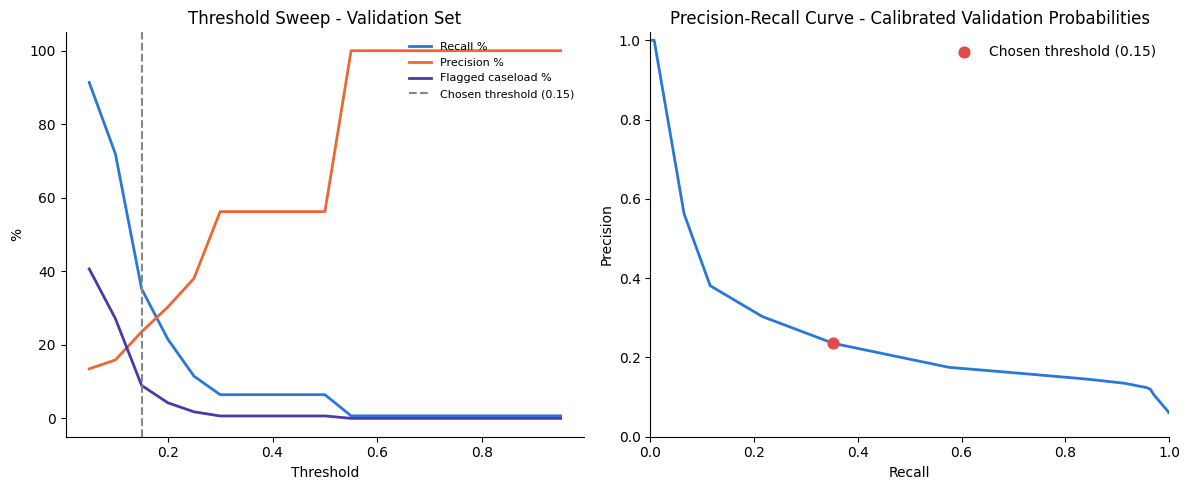

In [42]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"] * 100,
        color=PALETTE["blue"], linewidth=2, label="Recall %")
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"] * 100,
        color=PALETTE["orange"], linewidth=2, label="Precision %")
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["caseload_pct"],
        color=PALETTE["violet"], linewidth=2, label="Flagged caseload %")
ax.axvline(operating_threshold, color="#898781", linestyle="--", linewidth=1.5,
           label=f"Chosen threshold ({operating_threshold})")
ax.set_xlabel("Threshold")
ax.set_ylabel("%")
ax.set_title("Threshold Sweep - Validation Set")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_proba_calibrated)
ax.plot(recall_curve, precision_curve, color=PALETTE["blue"], linewidth=2)
ax.scatter([chosen_operating_point["recall"]], [chosen_operating_point["precision"]],
           color=PALETTE["red"], zorder=5, s=60,
           label=f"Chosen threshold ({operating_threshold})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Calibrated Validation Probabilities")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
save_figure(fig, "threshold_sweep_and_pr_curve.png", note=f"chosen threshold={operating_threshold}")
plt.show()

## 6. Step 3 — Risk Tiers

### Define tier boundaries

Boundaries are set on calibrated confidence and the resulting
workload/recall trade-off they produce — **not on monetary cost**. This
dataset has no claim-amount field, so there is no way to weigh "a $50,000
claim at 20% risk" against "a $2,000 claim at 60% risk"; a real deployment
would very likely want to, but that is out of scope here and should not be
implied by these tier names.

- **High** = calibrated probability >= the Step 2 operating threshold — the
  same claims that would be flagged for investigation.
- **Low** = calibrated probability below half the operating threshold — a
  confidence level clearly below the point already judged worth flagging.
- **Medium** = everything in between — a grey zone worth a lighter second
  look, not urgent, not dismissed.

Halving the operating threshold for the Low/Medium boundary is a simple,
transparent, adjustable rule anchored to the one threshold this notebook
already justified in Step 2, rather than a second independently-tuned cutoff.
The resulting workload and recall per tier — not the formula — is what
actually justifies it; see the table below.

In [43]:
HIGH_RISK_MIN = operating_threshold
LOW_RISK_MAX = round(operating_threshold / 2, 3)

assert LOW_RISK_MAX < HIGH_RISK_MIN, (
    f"Tier boundaries are out of order: LOW_RISK_MAX ({LOW_RISK_MAX}) should be "
    f"strictly less than HIGH_RISK_MIN ({HIGH_RISK_MIN})."
)


def assign_risk_tier(proba: np.ndarray, low_max: float, high_min: float) -> np.ndarray:
    """Low: proba < low_max. Medium: low_max <= proba < high_min. High: proba >= high_min."""
    return np.where(proba >= high_min, "High", np.where(proba >= low_max, "Medium", "Low"))


risk_tier = assign_risk_tier(y_proba_calibrated, LOW_RISK_MAX, HIGH_RISK_MIN)
print(f"Low: proba < {LOW_RISK_MAX}  |  Medium: {LOW_RISK_MAX} <= proba < {HIGH_RISK_MIN}  |  High: proba >= {HIGH_RISK_MIN}")

Low: proba < 0.075  |  Medium: 0.075 <= proba < 0.15  |  High: proba >= 0.15


### Per-tier validation report

In [44]:
def summarize_risk_tiers(tiers: np.ndarray, y_true: np.ndarray) -> pd.DataFrame:
    """Claim count, fraud count, fraud rate, and share of all fraud captured, per tier."""
    total_fraud = int(y_true.sum())
    rows = []
    for tier in ["Low", "Medium", "High"]:
        mask = tiers == tier
        n_claims = int(mask.sum())
        n_fraud = int(y_true[mask].sum())
        rows.append({
            "tier": tier,
            "n_claims": n_claims,
            "caseload_pct": round(100 * n_claims / len(y_true), 2),
            "n_fraud": n_fraud,
            "fraud_rate_pct": round(100 * n_fraud / n_claims, 2) if n_claims > 0 else 0.0,
            "recall_share_pct": round(100 * n_fraud / total_fraud, 2) if total_fraud > 0 else 0.0,
        })
    return pd.DataFrame(rows)


tier_summary_df = summarize_risk_tiers(risk_tier, y_val)
display(tier_summary_df)

assert int(tier_summary_df["n_claims"].sum()) == len(y_val), "Tiers do not partition all validation claims."
assert abs(tier_summary_df["recall_share_pct"].sum() - 100.0) < 0.5, "Tier recall shares do not sum to ~100%."
print("\nPASSED: tiers partition every validation claim exactly once, and their "
      "recall shares sum to ~100% of validation fraud.")

,tier,n_claims,caseload_pct,n_fraud,fraud_rate_pct,recall_share_pct
0,Low,1508,65.20,22,1.46,15.83
1,Medium,597,25.81,68,11.39,48.92
2,High,208,8.99,49,23.56,35.25



PASSED: tiers partition every validation claim exactly once, and their recall shares sum to ~100% of validation fraud.


## 7. Save `risk_config.json`

The single artifact later notebooks and the app need to score a new claim:
which calibrated model to use (`calibrated_model.joblib`), the operating
threshold, and the tier boundaries — all frozen here, all set on validation.

In [45]:
def to_jsonable(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value


risk_config = {
    "calibration_method": best_calibration_method,
    "calibrated_model_path": calibrated_model_path.name,
    "operating_threshold": to_jsonable(operating_threshold),
    "operating_point_metrics": {k: to_jsonable(v) for k, v in chosen_operating_point.items()},
    "threshold_selection_constraints": {
        "min_acceptable_precision": MIN_ACCEPTABLE_PRECISION,
        "max_acceptable_caseload_pct": MAX_ACCEPTABLE_CASELOAD_PCT,
    },
    "risk_tiers": {
        "definition": "Low: proba < low_max; Medium: low_max <= proba < high_min; High: proba >= high_min",
        "low_max": to_jsonable(LOW_RISK_MAX),
        "high_min": to_jsonable(HIGH_RISK_MIN),
        "basis": "calibrated model confidence + resulting validation workload/recall - NOT monetary cost (no claim-amount field in this dataset)",
    },
    "validation_tier_summary": tier_summary_df.to_dict(orient="records"),
    "pr_auc_before_calibration": to_jsonable(pr_auc_before),
    "pr_auc_after_calibration": to_jsonable(pr_auc_after),
    "source_model": {
        "model_name": best_model_config["model_name"],
        "balancing_strategy": best_model_config["balancing_strategy"],
        "optuna_trial_number": best_model_config["optuna"]["trial_number"],
    },
    "seed": RANDOM_STATE,
    "generated_at": datetime.now(timezone.utc).isoformat(),
}

risk_config_path = MODELS_DIR / "risk_config.json"
with open(risk_config_path, "w", encoding="utf-8") as f:
    json.dump(risk_config, f, indent=2)
saved_files.append(risk_config_path)
print(f"Saved -> {risk_config_path}")
display(Markdown(f"```json\n{json.dumps(risk_config, indent=2)}\n```"))

Saved -> /content/drive/MyDrive/InsuranceFraudProject/models/risk_config.json


```json
{
  "calibration_method": "isotonic",
  "calibrated_model_path": "calibrated_model.joblib",
  "operating_threshold": 0.15,
  "operating_point_metrics": {
    "threshold": 0.15,
    "recall": 0.35251798561151076,
    "precision": 0.23557692307692307,
    "fpr": 0.07313707451701931,
    "caseload_pct": 8.992650237786425,
    "tp": 49.0,
    "fp": 159.0,
    "fn": 90.0,
    "tn": 2015.0
  },
  "threshold_selection_constraints": {
    "min_acceptable_precision": 0.15,
    "max_acceptable_caseload_pct": 25.0
  },
  "risk_tiers": {
    "definition": "Low: proba < low_max; Medium: low_max <= proba < high_min; High: proba >= high_min",
    "low_max": 0.075,
    "high_min": 0.15,
    "basis": "calibrated model confidence + resulting validation workload/recall - NOT monetary cost (no claim-amount field in this dataset)"
  },
  "validation_tier_summary": [
    {
      "tier": "Low",
      "n_claims": 1508,
      "caseload_pct": 65.2,
      "n_fraud": 22,
      "fraud_rate_pct": 1.46,
      "recall_share_pct": 15.83
    },
    {
      "tier": "Medium",
      "n_claims": 597,
      "caseload_pct": 25.81,
      "n_fraud": 68,
      "fraud_rate_pct": 11.39,
      "recall_share_pct": 48.92
    },
    {
      "tier": "High",
      "n_claims": 208,
      "caseload_pct": 8.99,
      "n_fraud": 49,
      "fraud_rate_pct": 23.56,
      "recall_share_pct": 35.25
    }
  ],
  "pr_auc_before_calibration": 0.22253391147774496,
  "pr_auc_after_calibration": 0.21962625025079313,
  "source_model": {
    "model_name": "XGBoost",
    "balancing_strategy": "class_weight",
    "optuna_trial_number": 58
  },
  "seed": 42,
  "generated_at": "2026-08-29T09:53:45.411396+00:00"
}
```

## 8. Sanity Checks

Each check targets a specific way this notebook could go wrong.

### Calibration was fit only on data disjoint from the model's training set

In [46]:
assert set(train_df.index).isdisjoint(val_df.index), (
    "train_df and val_df share row indices - re-verified here as a hard stop, not "
    "just at first use in Section 4."
)
assert best_calibration_method in ("none", "sigmoid", "isotonic"), (
    f"Unexpected calibration method recorded: {best_calibration_method}"
)
print("PASSED: calibration was fit exclusively on validation data, disjoint from the "
      f"frozen model's training data. Selected method: '{best_calibration_method}'.")

PASSED: calibration was fit exclusively on validation data, disjoint from the frozen model's training data. Selected method: 'isotonic'.


### Calibration preserved ranking, and the operating threshold wasn't a hardcoded 0.5

In [47]:
assert pr_auc_gap < RANKING_TOLERANCE, "PR-AUC drifted more than the sanity tolerance after calibration."
assert 0.05 <= operating_threshold <= 0.95, (
    f"Operating threshold {operating_threshold} is outside the swept range - something is wrong "
    "with the selection logic."
)
print(f"PASSED: PR-AUC gap after calibration ({pr_auc_gap:.4f}) stayed within tolerance, "
      f"and the operating threshold ({operating_threshold}) was chosen from the swept "
      "recall/precision/workload trade-off, not hardcoded.")

PASSED: PR-AUC gap after calibration (0.0029) stayed within tolerance, and the operating threshold (0.15) was chosen from the swept recall/precision/workload trade-off, not hardcoded.


### Risk tiers are well-ordered and cost was never used

In [48]:
assert LOW_RISK_MAX < HIGH_RISK_MIN, "Risk tier boundaries are out of order."
assert set(np.unique(risk_tier)) <= {"Low", "Medium", "High"}, "Unexpected tier label produced."
assert "cost" not in risk_config["risk_tiers"]["basis"].lower() or "no claim-amount" in risk_config["risk_tiers"]["basis"].lower(), (
    "Risk tier basis text should explicitly disclaim cost-based tiering."
)
print("PASSED: Low < Medium < High boundaries are well-ordered, only three tier labels "
      "were produced, and the saved config explicitly disclaims cost-based tiering.")

PASSED: Low < Medium < High boundaries are well-ordered, only three tier labels were produced, and the saved config explicitly disclaims cost-based tiering.


### The test set was never touched

In [49]:
assert "test_df" not in dir() and "X_test" not in dir() and "y_test" not in dir(), (
    "Test set must not be loaded or referenced in this notebook - it is opened once, "
    "later, in Notebook 06."
)
print("PASSED: test.parquet / test_df / X_test / y_test are absent from this notebook's namespace.")

PASSED: test.parquet / test_df / X_test / y_test are absent from this notebook's namespace.


All sanity checks passed. If any of these fail on a re-run, treat it as a
hard stop before trusting `calibrated_model.joblib` or `risk_config.json`.

## Calibration & Thresholds Summary

In [50]:
summary_md = f"""
**Calibration:** compared uncalibrated, Platt (sigmoid), and isotonic on validation.
Selected **`{best_calibration_method}`** (Brier {best_brier:.4f}), cross-checked against
the reliability curve, not chosen on Brier alone. PR-AUC before/after:
{pr_auc_before:.4f} -> {pr_auc_after:.4f} (gap {pr_auc_gap:.4f}, within the
{RANKING_TOLERANCE} sanity tolerance) - ranking was preserved as expected for a
monotonic recalibration.

**Operating threshold:** **{operating_threshold}**, chosen to maximize recall subject to
precision >= {MIN_ACCEPTABLE_PRECISION} and flagged caseload <= {MAX_ACCEPTABLE_CASELOAD_PCT}%
on validation - a business trade-off, illustrative constraints, not a data-derived
constant. At this threshold: recall {chosen_operating_point['recall']:.3f}, precision
{chosen_operating_point['precision']:.3f}, caseload {chosen_operating_point['caseload_pct']:.1f}%
of validation claims.

**Risk tiers** (Low / Medium / High), from calibrated confidence and resulting
workload/recall — explicitly **not** from monetary cost (no claim-amount field in this
dataset):

{tier_summary_df.to_string(index=False)}

**All sanity checks passed:** calibration data confirmed disjoint from the model's
training data, ranking preserved within tolerance, tier boundaries well-ordered,
cost-based tiering explicitly disclaimed, and the test set was never referenced.

**Saved to Drive:** `calibrated_model.joblib`, `risk_config.json`, the reliability-curve
figure, and the threshold-sweep/PR-curve figure.

**What this notebook does not claim:** all numbers above are validation-set estimates
used to make a selection decision — not a real-world performance claim. The one,
single, honest performance number for this project comes from Notebook 06, evaluating
this frozen, calibrated, thresholded configuration on the test set exactly once.

**Open items for Notebook 06 onward:**
1. Notebook 06 loads `calibrated_model.joblib` and `risk_config.json` exactly as saved
   here and applies them to the test set - no re-tuning, no re-selection.
2. Notebook 07's SHAP analysis explains individual predictions from this frozen,
   calibrated model; it does not change the model, calibration, or thresholds.
"""
display(Markdown(summary_md))


**Calibration:** compared uncalibrated, Platt (sigmoid), and isotonic on validation.
Selected **`isotonic`** (Brier 0.0502), cross-checked against
the reliability curve, not chosen on Brier alone. PR-AUC before/after:
0.2225 -> 0.2196 (gap 0.0029, within the
0.02 sanity tolerance) - ranking was preserved as expected for a
monotonic recalibration.

**Operating threshold:** **0.15**, chosen to maximize recall subject to
precision >= 0.15 and flagged caseload <= 25.0%
on validation - a business trade-off, illustrative constraints, not a data-derived
constant. At this threshold: recall 0.353, precision
0.236, caseload 9.0%
of validation claims.

**Risk tiers** (Low / Medium / High), from calibrated confidence and resulting
workload/recall — explicitly **not** from monetary cost (no claim-amount field in this
dataset):

  tier  n_claims  caseload_pct  n_fraud  fraud_rate_pct  recall_share_pct
   Low      1508         65.20       22            1.46             15.83
Medium       597         25.81       68           11.39             48.92
  High       208          8.99       49           23.56             35.25

**All sanity checks passed:** calibration data confirmed disjoint from the model's
training data, ranking preserved within tolerance, tier boundaries well-ordered,
cost-based tiering explicitly disclaimed, and the test set was never referenced.

**Saved to Drive:** `calibrated_model.joblib`, `risk_config.json`, the reliability-curve
figure, and the threshold-sweep/PR-curve figure.

**What this notebook does not claim:** all numbers above are validation-set estimates
used to make a selection decision — not a real-world performance claim. The one,
single, honest performance number for this project comes from Notebook 06, evaluating
this frozen, calibrated, thresholded configuration on the test set exactly once.

**Open items for Notebook 06 onward:**
1. Notebook 06 loads `calibrated_model.joblib` and `risk_config.json` exactly as saved
   here and applies them to the test set - no re-tuning, no re-selection.
2. Notebook 07's SHAP analysis explains individual predictions from this frozen,
   calibrated model; it does not change the model, calibration, or thresholds.


### Files saved by this notebook

In [51]:
print("Calibration & threshold outputs written this run:")
for p in saved_files:
    print(f"  - {p}")

Calibration & threshold outputs written this run:
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/calibration/reliability_curve_comparison.png
  - /content/drive/MyDrive/InsuranceFraudProject/models/calibrated_model.joblib
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/calibration/threshold_sweep_and_pr_curve.png
  - /content/drive/MyDrive/InsuranceFraudProject/models/risk_config.json
